# Sleep Stage Classification — EOG-L + CNN-LSTM (Deep Learning)


In [ ]:
# Import Required Libraries

# File and directory handling
import os

# Numerical computations
import numpy as np

# EEG/EDF file processing
import mne

# PyTorch deep learning framework
import torch
import torch.nn as nn
import torch.optim as optim

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset and dataloader utilities
from torch.utils.data import Dataset, DataLoader

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    f1_score,
    cohen_kappa_score,
    confusion_matrix
)

# Compute class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

# Signal filtering functions
from scipy.signal import butter, filtfilt

# Progress bar
from tqdm import tqdm

# XML annotation processing
import xml.etree.ElementTree as ET

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'pyedflib'], check=True)

CompletedProcess(args=['pip', 'install', 'pyedflib'], returncode=0)

## Bandpass Filter (0.3–35 Hz)


In [ ]:
# Apply Butterworth bandpass filter
def bandpass_filter(
    signal,
    fs,
    lowcut=0.3,
    highcut=35,
    order=4
):

    # Compute Nyquist frequency
    nyquist = 0.5 * fs

    # Normalize cutoff frequencies
    low = lowcut / nyquist
    high = highcut / nyquist

    # Create bandpass filter
    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    # Apply zero-phase filtering
    return filtfilt(
        b,
        a,
        signal
    ).astype(np.float32)

## Load EOG + Apply Filter


In [ ]:
import pyedflib

# Load and preprocess EOG-L signal
def load_eog(file_path):

    with pyedflib.EdfReader(file_path) as f:

        # Get channel names
        ch_names = f.getSignalLabels()

        # Get sampling frequencies
        fs_list = f.getSampleFrequencies()

        # Find EOG-L channel index
        eog_l_idx = next(

            (
                i for i, ch in enumerate(ch_names)
                if ch.strip() == 'EOG-L'
            ),

            None
        )

        # Raise error if channel is missing
        if eog_l_idx is None:

            raise ValueError(
                f"Channel EOG-L not found in {ch_names}"
            )

        # Read EOG signal
        eog = f.readSignal(
            eog_l_idx
        ).astype(np.float32)

        # Sampling frequency
        fs = int(fs_list[eog_l_idx])

    # Apply bandpass filter
    eog = bandpass_filter(eog, fs)

    return eog.astype(np.float32), fs

## Create Epochs (30 sec)


In [ ]:
# Split signal into fixed-length epochs
def create_epochs(
    signal,
    fs,
    epoch_duration=30
):

    # Number of samples per epoch
    samples = fs * epoch_duration

    # Total number of complete epochs
    num_epochs = len(signal) // samples

    # Create epochs
    return np.array([

        signal[
            i * samples:(i + 1) * samples
        ]

        for i in range(num_epochs)
    ])

## Load XML Labels


In [ ]:
# Load sleep stage labels from XML annotation file
def load_labels(xml_file):

    # Read XML file
    tree = ET.parse(xml_file)
    root = tree.getroot()

    labels = []

    # Loop through all scored events
    for event in root.iter('ScoredEvent'):

        concept = event.find('EventConcept')
        duration = event.find('Duration')

        # Skip incomplete events
        if concept is None or duration is None:
            continue

        stage = concept.text
        duration = float(duration.text)

        # Keep only sleep stage events
        if (
            "Stage" not in stage
            and "REM" not in stage
            and "Wake" not in stage
        ):
            continue

        # Convert duration to number of epochs
        num_epochs = int(duration / 30)

        # Map stages to labels
        if 'Wake' in stage:

            label = 0

        elif 'Stage 1' in stage:

            label = 1

        elif 'Stage 2' in stage:

            label = 2

        elif (
            'Stage 3' in stage
            or 'Stage 4' in stage
        ):

            label = 3

        elif 'REM' in stage:

            label = 4

        else:
            continue

        # Add labels for all epochs
        labels.extend(
            [label] * num_epochs
        )

    return np.array(labels)

## Normalize


In [ ]:
# Apply z-score normalization
def normalize(epochs):

    # Create scaler object
    scaler = StandardScaler()

    # Reshape data for normalization
    reshaped = epochs.reshape(-1, 1)

    # Normalize data
    normalized = scaler.fit_transform(
        reshaped
    )

    # Restore original shape
    return normalized.reshape(
        epochs.shape
    )

## Create Sequences — داخل كل subject بس ✅


In [ ]:
# Create sequences from epochs inside the same subject
def create_sequences_per_subject(
    epochs,
    labels,
    seq_len=10
):

    # Prevent mixing epochs
    # from different subjects

    X_seq = []
    y_seq = []

    for i in range(
        len(epochs) - seq_len
    ):

        # Consecutive epochs as input
        X_seq.append(
            epochs[i:i + seq_len]
        )

        # Target label
        # of the next epoch
        y_seq.append(
            labels[i + seq_len]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

## Load Dataset — Subject by Subject ✅


In [ ]:
# Load and preprocess all subjects
def load_all_subjects(
    data_path,
    ann_path,
    seq_len=10
):

    # Store processed subjects
    subjects = []

    # Get all EDF files
    files = sorted([

        f for f in os.listdir(data_path)

        if f.endswith('.edf')
    ])

    for file in files:

        edf_path = os.path.join(
            data_path,
            file
        )

        # Match EDF file with XML annotation
        xml_path = os.path.join(

            ann_path,

            file.replace(
                '.edf',
                '-nsrr.xml'
            )
        )

        # Skip if annotation file is missing
        if not os.path.exists(xml_path):

            print(
                f"Skipped (no annotation): {file}"
            )

            continue

        try:
            # Load EOG signal
            signal, fs = load_eog(edf_path)

            # Split signal into epochs
            epochs = create_epochs(
                signal,
                fs
            )

            # Load sleep stage labels
            labels = load_labels(xml_path)

            # Make lengths equal
            min_len = min(
                len(epochs),
                len(labels)
            )

            epochs = epochs[:min_len]
            labels = labels[:min_len]

            # Normalize epochs
            epochs = normalize(epochs)

            # Create sequences
            # only inside the same subject
            X_seq, y_seq = create_sequences_per_subject(

                epochs,
                labels,
                seq_len
            )

            # Save subject data
            subjects.append(
                (X_seq, y_seq)
            )

            print(

                f"Loaded: {file} — "
                f"{len(epochs)} epochs → "
                f"{len(X_seq)} sequences"
            )

        except Exception as e:

            print(
                f"Skipped {file}: {e}"
            )

    return subjects

### Subject-Level Data Split✅


In [ ]:
# Split dataset at subject level
def split_subjects(
    subjects,
    train_ratio=0.7,
    val_ratio=0.2
):

    n = len(subjects)

    # Number of subjects in each split
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    # Split subjects
    train_subjects = subjects[:n_train]

    val_subjects = subjects[
        n_train:n_train + n_val
    ]

    test_subjects = subjects[
        n_train + n_val:
    ]

    # Concatenate sequences
    # from multiple subjects
    def concat(subj_list):

        X = np.concatenate([
            s[0] for s in subj_list
        ])

        y = np.concatenate([
            s[1] for s in subj_list
        ])

        return X, y

    # Create train / val / test sets
    X_train, y_train = concat(
        train_subjects
    )

    X_val, y_val = concat(
        val_subjects
    )

    X_test, y_test = concat(
        test_subjects
    )

    # Print split information
    print(

        f"Train: {len(train_subjects)} subjects → "
        f"{len(X_train)} sequences"
    )

    print(

        f"Val  : {len(val_subjects)} subjects → "
        f"{len(X_val)} sequences"
    )

    print(

        f"Test : {len(test_subjects)} subject → "
        f"{len(X_test)} sequences"
    )

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )

## Dataset Class


In [ ]:
class SleepDataset(Dataset):

    def __init__(self, X, y):

        # Convert data to PyTorch tensors
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        # Total number of samples
        return len(self.X)

    def __getitem__(self, idx):

        # Return one sample and its label
        return (
            self.X[idx],
            self.y[idx]
        )

## CNN + LSTM Model


In [ ]:
class CNNEncoder(nn.Module):

    # CNN extracts features from a single epoch

    def __init__(self, out_dim=128):

        super().__init__()

        self.net = nn.Sequential(

            # First convolution block
            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.MaxPool1d(4),

            nn.Dropout(0.2),

            # Second convolution block
            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.MaxPool1d(4),

            nn.Dropout(0.2),

            # Final feature extraction block
            nn.Conv1d(
                64,
                out_dim,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(out_dim),
            nn.ReLU(),

            # Reduce temporal dimension
            nn.AdaptiveAvgPool1d(1)
        )

    def forward(self, x):

        # Output:
        # (batch, out_dim, 1)
        # → (batch, out_dim)

        return self.net(x).squeeze(-1)


class SleepModel(nn.Module):

    def __init__(
        self,
        cnn_out=128,
        lstm_hidden=256,
        lstm_layers=2,
        num_classes=5,
        dropout=0.3
    ):

        super().__init__()

        # CNN feature extractor
        self.cnn = CNNEncoder(
            out_dim=cnn_out
        )

        # Bidirectional LSTM
        self.lstm = nn.LSTM(

            input_size=cnn_out,

            hidden_size=lstm_hidden,

            num_layers=lstm_layers,

            batch_first=True,

            dropout=dropout,

            # Read sequence
            # in both directions
            bidirectional=True
        )

        # Final classifier
        self.classifier = nn.Sequential(

            # *2 Because of BiLSTM
            nn.Linear(
                lstm_hidden * 2,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        # x shape:
        # (batch, seq_len, timesteps)

        batch, seq_len, timesteps = x.shape

        # Apply CNN to each epoch

        x = x.view(
            batch * seq_len,
            1,
            timesteps
        )

        # Extract epoch features
        x = self.cnn(x)

        # Reshape for LSTM
        x = x.view(
            batch,
            seq_len,
            -1
        )

        # Apply LSTM to sequence

        lstm_out, _ = self.lstm(x)

        # Last timestep output
        last = lstm_out[:, -1, :]

        # Final prediction
        return self.classifier(last)

## Training Function


In [ ]:
# Train the model
def train_model(
    model,
    train_loader,
    val_loader,
    weights,
    epochs=30
):

    # Use GPU if available
    device = torch.device(
        'cuda'
        if torch.cuda.is_available()
        else 'cpu'
    )

    print('Using:', device)

    model.to(device)

    # Adam optimizer
    optimizer = optim.Adam(

        model.parameters(),

        lr=0.001,

        # L2 regularization
        weight_decay=1e-4
    )

    # Reduce learning rate
    # if validation loss stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode='min',

        patience=3,

        factor=0.5,

        verbose=True
    )

    # Cross entropy loss
    # with class weights
    criterion = nn.CrossEntropyLoss(
        weight=weights.to(device)
    )

    # Early stopping variables
    best_loss = float('inf')

    patience_counter = 0

    early_stop_patience = 7

    # Store training history
    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        # ====================================================
        # Training phase
        # ====================================================

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for X, y in tqdm(

            train_loader,

            desc=f'Epoch {epoch+1}/{epochs}'
        ):

            X = X.to(device)
            y = y.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(X)

            # Compute loss
            loss = criterion(outputs, y)

            # Backpropagation
            loss.backward()

            # Prevent gradient explosion
            nn.utils.clip_grad_norm_(

                model.parameters(),

                max_norm=1.0
            )

            # Update weights
            optimizer.step()

            total_loss += loss.item()

            # Count correct predictions
            correct += (

                torch.argmax(outputs, 1) == y

            ).sum().item()

            total += y.size(0)

        # Average training metrics
        train_loss = total_loss / len(train_loader)

        train_acc = correct / total

        # ====================================================
        # Validation phase
        # ====================================================

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for X, y in val_loader:

                X = X.to(device)
                y = y.to(device)

                # Forward pass
                outputs = model(X)

                # Validation loss
                loss = criterion(outputs, y)

                val_loss += loss.item()

                # Count correct predictions
                correct += (

                    torch.argmax(outputs, 1) == y

                ).sum().item()

                total += y.size(0)

        # Average validation metrics
        val_loss /= len(val_loader)

        val_acc = correct / total

        # Update scheduler
        scheduler.step(val_loss)

        # Save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(

            f'Epoch {epoch+1}: '

            f'Train Loss={train_loss:.4f} '

            f'Acc={train_acc:.4f} | '

            f'Val Loss={val_loss:.4f} '

            f'Acc={val_acc:.4f}'
        )

        # Save best model
        if val_loss < best_loss:

            best_loss = val_loss

            patience_counter = 0

            torch.save(
                model.state_dict(),
                'best.pth'
            )

            print('Saved best model')

        else:

            patience_counter += 1

            # Stop training
            # if validation loss does not improve
            if patience_counter >= early_stop_patience:

                print('Early stopping')

                break

    return (
        train_losses,
        val_losses,
        train_accs,
        val_accs
    )

## Evaluation


In [ ]:
# Evaluate model performance
def evaluate(
    model,
    test_loader
):

    # Use GPU if available
    device = torch.device(

        'cuda'

        if torch.cuda.is_available()

        else 'cpu'
    )

    # Load best saved model
    model.load_state_dict(

        torch.load(
            'best.pth',
            map_location=device
        )
    )

    model.to(device)

    model.eval()

    preds = []
    labels = []

    # Disable gradients during evaluation
    with torch.no_grad():

        for X, y in test_loader:

            X = X.to(device)

            # Forward pass
            outputs = model(X)

            # Predicted class
            p = torch.argmax(
                outputs,
                1
            ).cpu().numpy()

            preds.extend(p)

            labels.extend(
                y.numpy()
            )

    # Sleep stage names
    target_names = [

        'Wake',
        'Stage 1',
        'Stage 2',
        'Stage 3/4',
        'REM'
    ]

    # Print classification report
    print(

        classification_report(

            labels,
            preds,

            target_names=target_names
        )
    )

    # Print Macro F1 score
    print(

        'Macro F1 :',

        round(

            f1_score(
                labels,
                preds,
                average='macro'
            ),

            4
        )
    )

    # Print Cohen Kappa score
    print(

        'Cohen Kappa:',

        round(

            cohen_kappa_score(
                labels,
                preds
            ),

            4
        )
    )

    return preds, labels

## Plot Training Curves


In [ ]:
# Plot training curves
def plot_results(
    train_losses,
    val_losses,
    train_accs,
    val_accs
):

    # Create figure
    plt.figure(figsize=(12, 5))

    # ====================================================
    # Loss curves
    # ====================================================

    plt.subplot(1, 2, 1)

    plt.plot(
        train_losses,
        label='Train Loss'
    )

    plt.plot(
        val_losses,
        label='Val Loss'
    )

    plt.legend()

    plt.title('Loss Curve')

    plt.xlabel('Epoch')

    # ====================================================
    # Accuracy curves
    # ====================================================

    plt.subplot(1, 2, 2)

    plt.plot(
        train_accs,
        label='Train Acc'
    )

    plt.plot(
        val_accs,
        label='Val Acc'
    )

    plt.legend()

    plt.title('Accuracy Curve')

    plt.xlabel('Epoch')

    # Adjust layout
    plt.tight_layout()

    # Save figure
    plt.savefig(

        'training_curves.png',

        dpi=150,

        bbox_inches='tight'
    )

    plt.show()

## Plot Confusion Matrix


In [ ]:
# Plot confusion matrix
def plot_confusion_matrix(
    labels,
    preds
):

    # Sleep stage names
    class_names = [

        'Wake',
        'Stage 1',
        'Stage 2',
        'Stage 3/4',
        'REM'
    ]

    # Compute confusion matrix
    cm = confusion_matrix(
        labels,
        preds
    )

    # Normalize confusion matrix
    cm_norm = cm.astype('float') / cm.sum(
        axis=1,
        keepdims=True
    )

    # Create figure
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6)
    )

    # ====================================================
    # Raw confusion matrix
    # ====================================================

    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='Blues',

        xticklabels=class_names,

        yticklabels=class_names,

        ax=axes[0],

        linewidths=0.5
    )

    axes[0].set_title(

        'Confusion Matrix — Raw Counts',

        fontsize=14,

        fontweight='bold'
    )

    axes[0].set_xlabel(
        'Predicted Label'
    )

    axes[0].set_ylabel(
        'True Label'
    )

    # ====================================================
    # Normalized confusion matrix
    # ====================================================

    sns.heatmap(

        cm_norm,

        annot=True,

        fmt='.2f',

        cmap='YlOrRd',

        xticklabels=class_names,

        yticklabels=class_names,

        ax=axes[1],

        linewidths=0.5,

        vmin=0,

        vmax=1
    )

    axes[1].set_title(

        'Confusion Matrix — Normalized (Recall)',

        fontsize=14,

        fontweight='bold'
    )

    axes[1].set_xlabel(
        'Predicted Label'
    )

    axes[1].set_ylabel(
        'True Label'
    )

    # Main title
    plt.suptitle(

        'Sleep Stage Classification Results',

        fontsize=16,

        fontweight='bold'
    )

    plt.tight_layout()

    # Save figure
    plt.savefig(

        'confusion_matrix.png',

        dpi=150,

        bbox_inches='tight'
    )

    plt.show()

---
## ▶️ Run the Complete Sleep Staging Pipeline


In [17]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU — using CPU')


True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
# Dataset paths
data_path = r"C:\Users\Laptop\Desktop\Project\Signals"

ann_path = r"C:\Users\Laptop\Desktop\Project\Annotations"

# Number of epochs in each sequence
SEQ_LEN = 10

## 📋 Display All Channels in the Dataset File

📂 File: mesa-sleep-0001.edf
Number of channels: 27
Recording duration: 12.00 hours (43199 seconds)

#     Channel Name         Fs (Hz)      Samples     
----------------------------------------------------
0     EKG                  256          11,058,944  
1     EOG-L                256          11,058,944  
2     EOG-R                256          11,058,944  
3     EMG                  256          11,058,944  
4     EEG1                 256          11,058,944  
5     EEG2                 256          11,058,944  
6     EEG3                 256          11,058,944  
7     Pres                 32           1,382,368   
8     Flow                 32           1,382,368   
9     Snore                32           1,382,368   
10    Thor                 32           1,382,368   
11    Abdo                 32           1,382,368   
12    Leg                  32           1,382,368   
13    Therm                32           1,382,368   
14    Pos                  32           1,382,368   

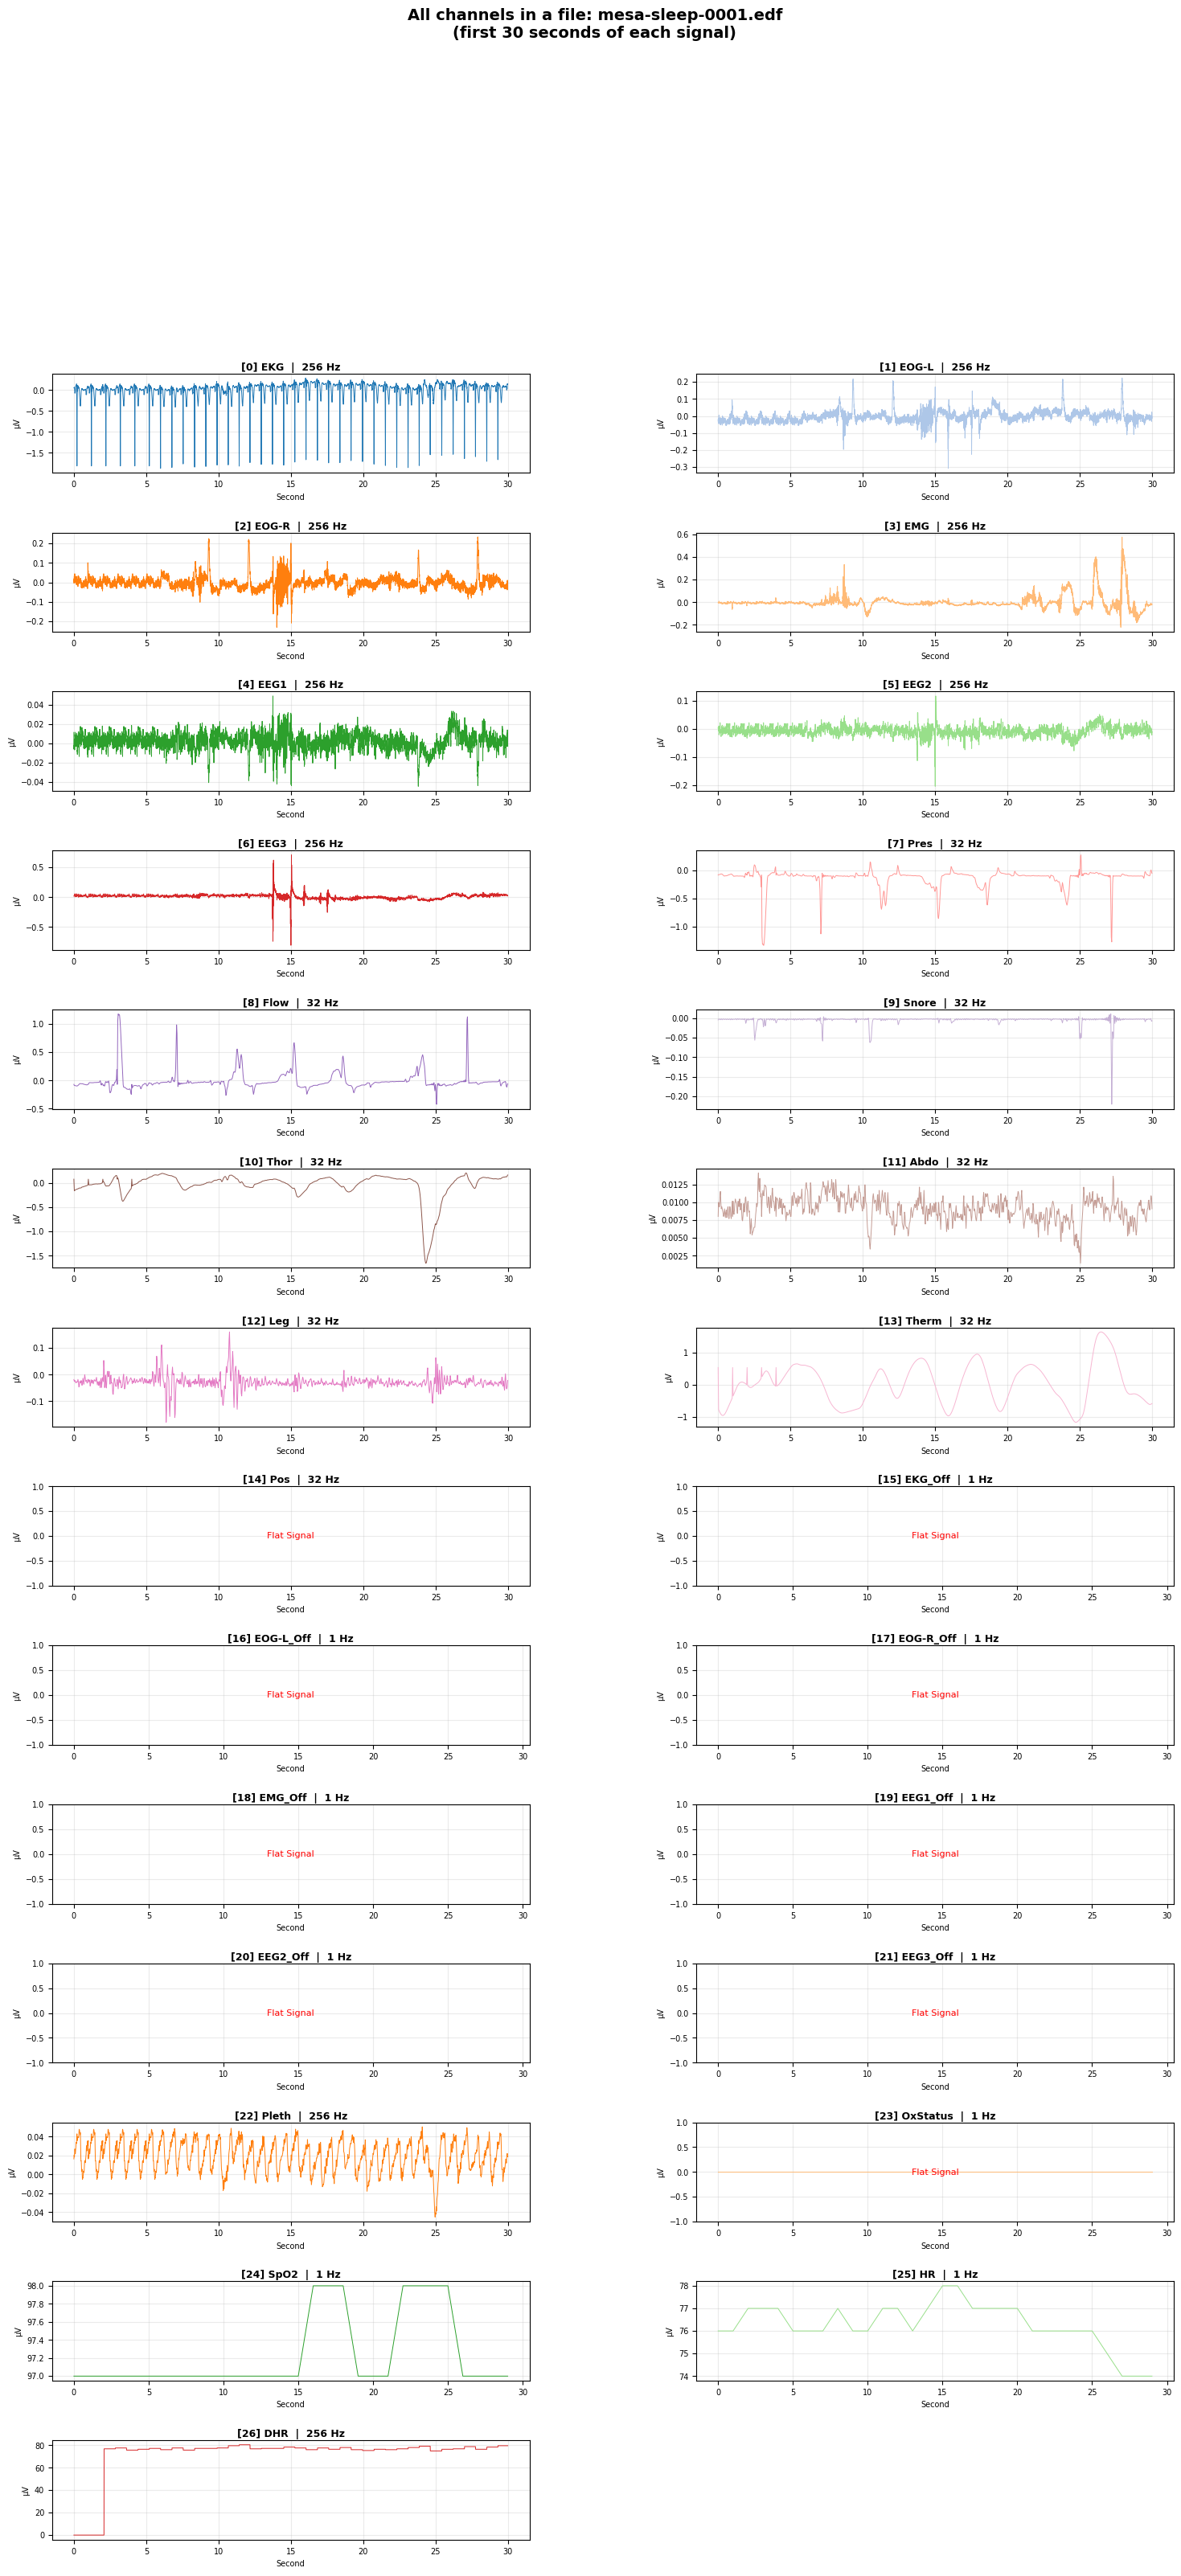


✅ تم حفظ الرسم في: all_channels.png


In [ ]:
# ================================================================
# Display all channels from the first EDF file
# Shows:
# - Channel name
# - Sampling rate
# - Signal waveform
# ================================================================

import pyedflib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load the first EDF file
files = sorted([

    f for f in os.listdir(data_path)

    if f.endswith('.edf')
])

sample_file = os.path.join(
    data_path,
    files[0]
)

print(f'File: {files[0]}')

print('=' * 60)

with pyedflib.EdfReader(sample_file) as f:

    # Read EDF metadata
    ch_names = f.getSignalLabels()

    fs_list = f.getSampleFrequencies()

    n_channels = f.signals_in_file

    duration_s = f.getFileDuration()

    print(
        f'Number of channels: {n_channels}'
    )

    print(

        f'Recording duration: '
        f'{duration_s / 3600:.2f} hours '
        f'({duration_s:.0f} seconds)'
    )

    print()

    # Print channel information table
    print(
        f'{"#":<5} '
        f'{"Channel Name":<20} '
        f'{"Fs (Hz)":<12} '
        f'{"Samples":<12}'
    )

    print('-' * 52)

    signals = []

    for i in range(n_channels):

        # Read channel signal
        sig = f.readSignal(i).astype(
            np.float32
        )

        signals.append(sig)

        print(

            f'{i:<5} '

            f'{ch_names[i]:<20} '

            f'{int(fs_list[i]):<12} '

            f'{len(sig):<12,}'
        )

# ================================================================
# Plot signals
# ================================================================

# Show first 30 seconds only
show_sec = 30

# Grid layout
n_cols = 2

n_rows = (
    n_channels + n_cols - 1
) // n_cols

fig = plt.figure(
    figsize=(18, n_rows * 2.5)
)

gs = gridspec.GridSpec(

    n_rows,
    n_cols,

    figure=fig,

    hspace=0.6,
    wspace=0.35
)

# Use different colors
colors = plt.cm.tab20.colors

for i in range(n_channels):

    row, col = divmod(i, n_cols)

    ax = fig.add_subplot(
        gs[row, col]
    )

    sig = signals[i]

    fs = int(fs_list[i])

    # Number of displayed samples
    n = min(
        show_sec * fs,
        len(sig)
    )

    # Time axis
    t = np.arange(n) / fs

    # Plot signal
    ax.plot(

        t,
        sig[:n],

        color=colors[i % len(colors)],

        linewidth=0.7
    )

    ax.set_title(

        f'[{i}] '
        f'{ch_names[i].strip()} | {fs} Hz',

        fontsize=9,

        fontweight='bold',

        pad=3
    )

    ax.set_xlabel(
        'Second',
        fontsize=7
    )

    ax.set_ylabel(
        'µV',
        fontsize=7
    )

    ax.tick_params(
        labelsize=7
    )

    ax.grid(
        True,
        alpha=0.25
    )

    # Detect flat signals
    if sig[:n].std() < 1e-6:

        ax.set_ylim(-1, 1)

        ax.text(

            0.5,
            0.5,

            'Flat Signal',

            transform=ax.transAxes,

            ha='center',
            va='center',

            color='red',

            fontsize=8
        )

# Hide empty subplot
# if number of channels is odd
if n_channels % n_cols != 0:

    fig.add_subplot(

        gs[n_rows - 1, n_cols - 1]

    ).axis('off')

# Main title
fig.suptitle(

    f'All channels in file: {files[0]}\n'
    f'(first 30 seconds of each signal)',

    fontsize=14,

    fontweight='bold',

    y=1.01
)

# Save figure
plt.savefig(

    'all_channels.png',

    dpi=150,

    bbox_inches='tight'
)

plt.show()

print('\nFigure saved as: all_channels.png')

📂 Annotation File: mesa-sleep-0001-nsrr.xml
Number of annotations: 259


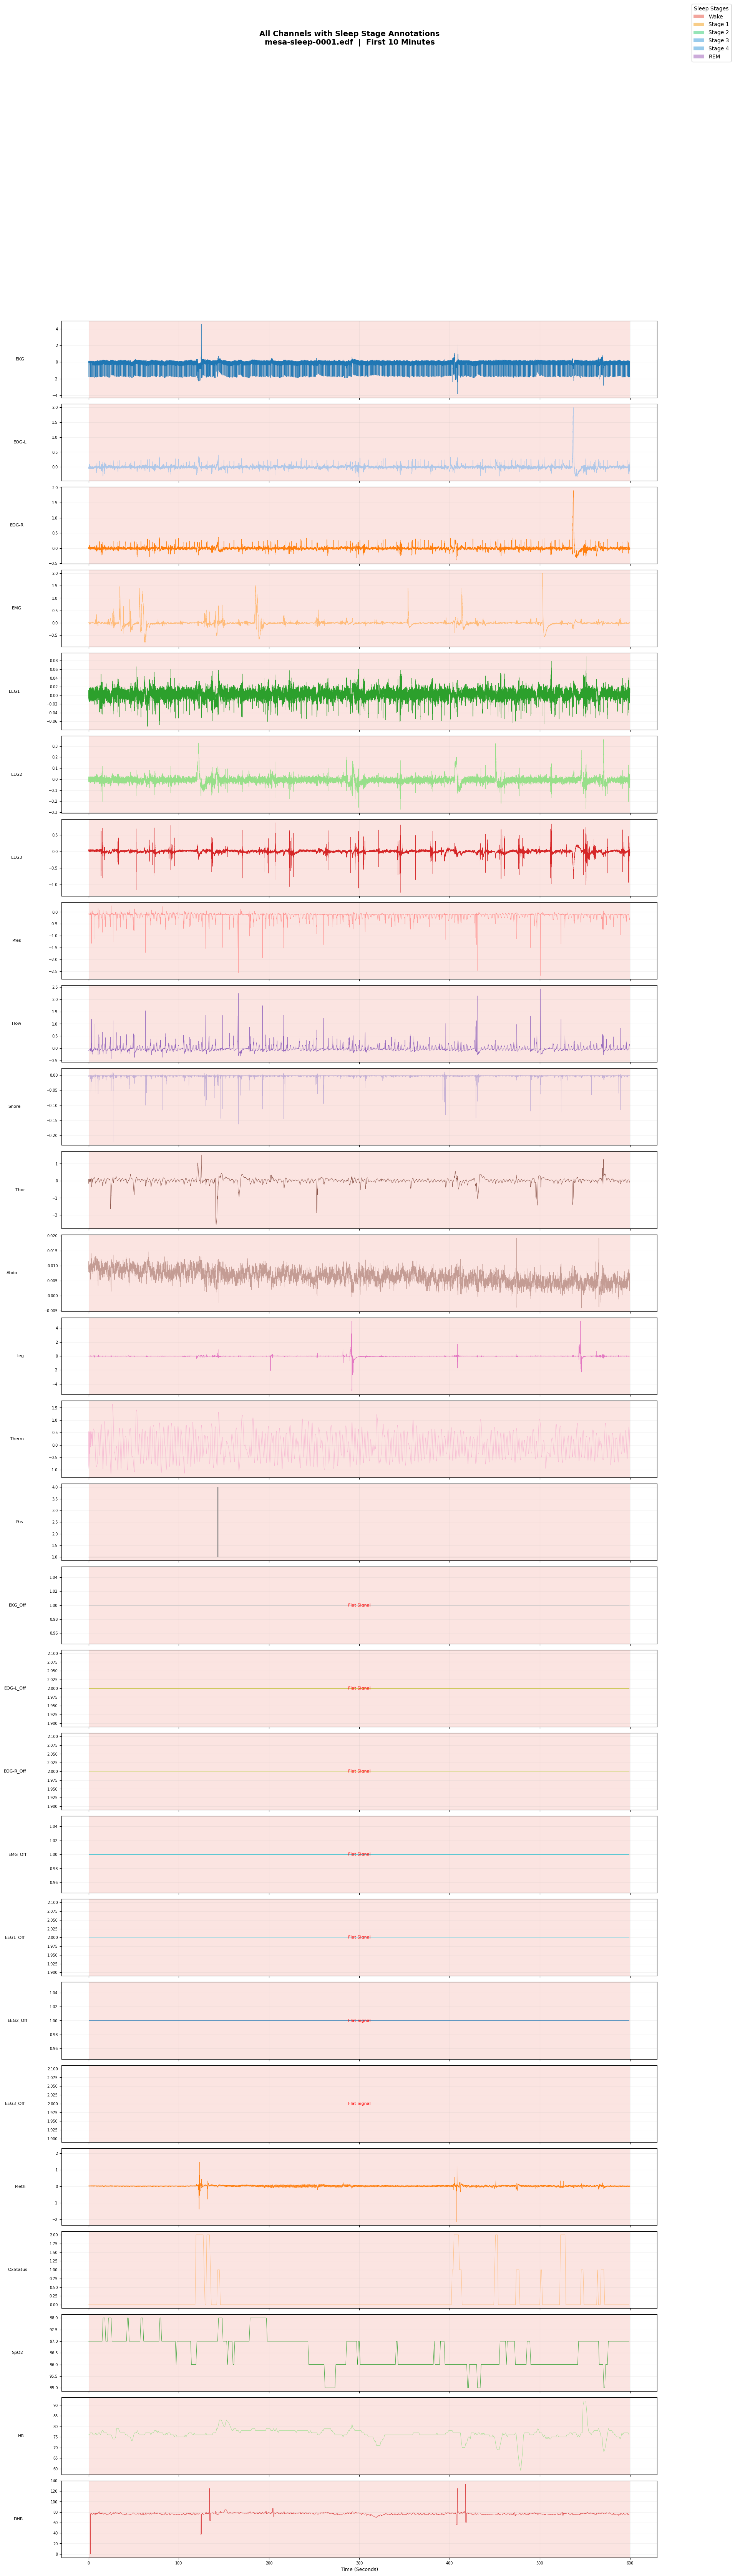

✅ Figure saved as: all_channels_annotated.png


In [ ]:
# ================================================================
# Display all channels with sleep stage annotations
# ================================================================

import xml.etree.ElementTree as ET

from matplotlib.patches import Patch

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

import numpy as np
import os

# ================================================================
# Load the first annotation file
# ================================================================

xml_files = sorted([

    f for f in os.listdir(ann_path)

    if f.endswith('.xml')
])

sample_xml = os.path.join(
    ann_path,
    xml_files[0]
)

print(
    f'Annotation File: {xml_files[0]}'
)

# ================================================================
# Sleep stage colors
# ================================================================

stage_colors = {

    'Wake': ('#e74c3c', 0),

    'Stage 1': ('#f39c12', 1),

    'Stage 2': ('#2ecc71', 2),

    'Stage 3': ('#3498db', 3),

    'Stage 4': ('#3498db', 3),

    'REM': ('#9b59b6', 4),
}

events = []

# ================================================================
# Read sleep stage annotations
# ================================================================

tree = ET.parse(sample_xml)

root = tree.getroot()

for event in root.iter('ScoredEvent'):

    concept = event.find('EventConcept')

    start = event.find('Start')

    duration = event.find('Duration')

    # Skip incomplete events
    if (
        concept is None
        or start is None
        or duration is None
    ):
        continue

    stage = concept.text

    # Match sleep stage name
    for key in stage_colors:

        if key in stage:

            events.append({

                'stage': key,

                'start': float(start.text),

                'duration': float(duration.text),

                'color': stage_colors[key][0]
            })

            break

print(
    f'Number of annotations: {len(events)}'
)

# ================================================================
# Plot all channels
# with sleep stage background colors
# ================================================================

# Show first 10 minutes
show_sec = 600

fig = plt.figure(
    figsize=(20, n_channels * 2.8)
)

gs = gridspec.GridSpec(

    n_channels,
    1,

    figure=fig,

    hspace=0.08
)

for i in range(n_channels):

    ax = fig.add_subplot(gs[i])

    sig = signals[i]

    fs = int(fs_list[i])

    # Number of displayed samples
    n = min(
        show_sec * fs,
        len(sig)
    )

    # Time axis
    t = np.arange(n) / fs

    # ============================================================
    # Draw sleep stage background
    # ============================================================

    for ev in events:

        # Skip events outside range
        if ev['start'] > show_sec:
            continue

        end = min(

            ev['start'] + ev['duration'],

            show_sec
        )

        ax.axvspan(

            ev['start'],
            end,

            alpha=0.15,

            color=ev['color'],

            linewidth=0
        )

    # ============================================================
    # Plot signal
    # ============================================================

    ax.plot(

        t,
        sig[:n],

        color=colors[i % len(colors)],

        linewidth=0.6
    )

    # Hide x-axis labels
    # except for the last subplot
    if i < n_channels - 1:

        ax.set_xticklabels([])

    else:

        ax.set_xlabel(
            'Time (Seconds)',
            fontsize=9
        )

    # Channel label
    ax.set_ylabel(

        ch_names[i].strip(),

        fontsize=8,

        rotation=0,

        labelpad=60,

        va='center'
    )

    ax.tick_params(
        labelsize=7
    )

    ax.grid(
        True,
        alpha=0.15
    )

    # Detect flat signals
    if sig[:n].std() < 1e-6:

        ax.text(

            0.5,
            0.5,

            'Flat Signal',

            transform=ax.transAxes,

            ha='center',
            va='center',

            color='red',

            fontsize=8
        )

# ================================================================
# Sleep stage legend
# ================================================================

legend_elements = [

    Patch(

        facecolor=v[0],

        alpha=0.5,

        label=k
    )

    for k, v in stage_colors.items()
]

fig.legend(

    handles=legend_elements,

    loc='upper right',

    fontsize=10,

    title='Sleep Stages',

    framealpha=0.9,

    bbox_to_anchor=(1.0, 0.99)
)

# ================================================================
# Main title
# ================================================================

fig.suptitle(

    f'All Channels with Sleep Stage Annotations\n'
    f'{files[0]} | First {show_sec // 60} Minutes',

    fontsize=14,

    fontweight='bold'
)

# ================================================================
# Save figure
# ================================================================

plt.savefig(

    'all_channels_annotated.png',

    dpi=150,

    bbox_inches='tight'
)

plt.show()

print(
    'Figure saved as: all_channels_annotated.png'
)

## 📊  Cell 1 — Display Raw EOG-L Signal


Reading File: mesa-sleep-0001.edf
Sampling Rate: 256 Hz  |  Total Samples: 11,058,944  |  Duration: 720.0 minutes


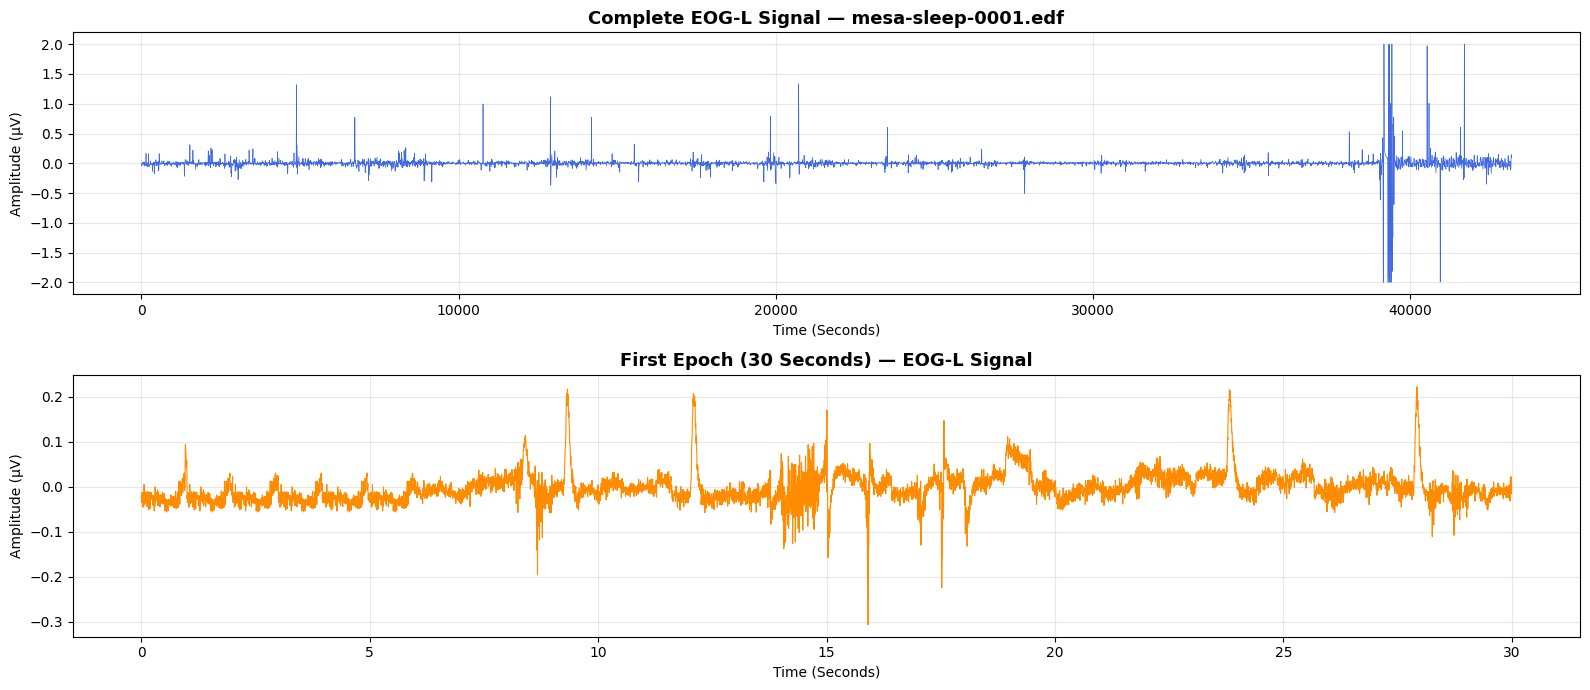

✅ Figure saved as: cell1_general_signal_l.png


In [22]:

# ========================================================
# Read the first EDF file
# ========================================================

files = sorted([
    f for f in os.listdir(data_path)
    if f.endswith('.edf')
])

sample_file = os.path.join(data_path, files[0])

print(f'Reading File: {files[0]}')

# ========================================================
# Read Raw EOG-L Signal Before Any Processing
# ========================================================

with pyedflib.EdfReader(sample_file) as f:

    ch_names = f.getSignalLabels()

    fs_list = f.getSampleFrequencies()

    # Find EOG-L channel index
    eog_l_idx = next(
        (i for i, ch in enumerate(ch_names)
         if ch.strip() == 'EOG-L'),
        None
    )

    if eog_l_idx is None:
        raise ValueError("EOG-L channel not found!")

    raw_signal = f.readSignal(eog_l_idx).astype(np.float32)

    fs = int(fs_list[eog_l_idx])

# ========================================================
# Signal Information
# ========================================================

print(
    f'Sampling Rate: {fs} Hz  |  '
    f'Total Samples: {len(raw_signal):,}  |  '
    f'Duration: {len(raw_signal) / fs / 60:.1f} minutes'
)

# ========================================================
# Time Axis
# ========================================================

t = np.arange(len(raw_signal)) / fs

show_sec = 30

n_show = show_sec * fs

# ========================================================
# Plotting
# ========================================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 7)
)

# --------------------------------------------------------
# Plot 1 — Full Signal (Downsampled for Visualization)
# --------------------------------------------------------

step = max(1, len(raw_signal) // 5000)

axes[0].plot(
    t[::step],
    raw_signal[::step],
    color='royalblue',
    linewidth=0.5
)

axes[0].set_title(
    f'Complete EOG-L Signal — {files[0]}',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Time (Seconds)')

axes[0].set_ylabel('Amplitude (µV)')

axes[0].grid(True, alpha=0.3)

# --------------------------------------------------------
# Plot 2 — First 30 Seconds (One Epoch)
# --------------------------------------------------------

axes[1].plot(
    t[:n_show],
    raw_signal[:n_show],
    color='darkorange',
    linewidth=0.8
)

axes[1].set_title(
    'First Epoch (30 Seconds) — EOG-L Signal',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel('Time (Seconds)')

axes[1].set_ylabel('Amplitude (µV)')

axes[1].grid(True, alpha=0.3)

# ========================================================
# Save and Display Figure
# ========================================================

plt.tight_layout()

plt.savefig(
    'cell1_general_signal_l.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('✅ Figure saved as: cell1_general_signal_l.png')

## 📊 Cell 2 — Display EOG-L and EOG-R Signals Separately

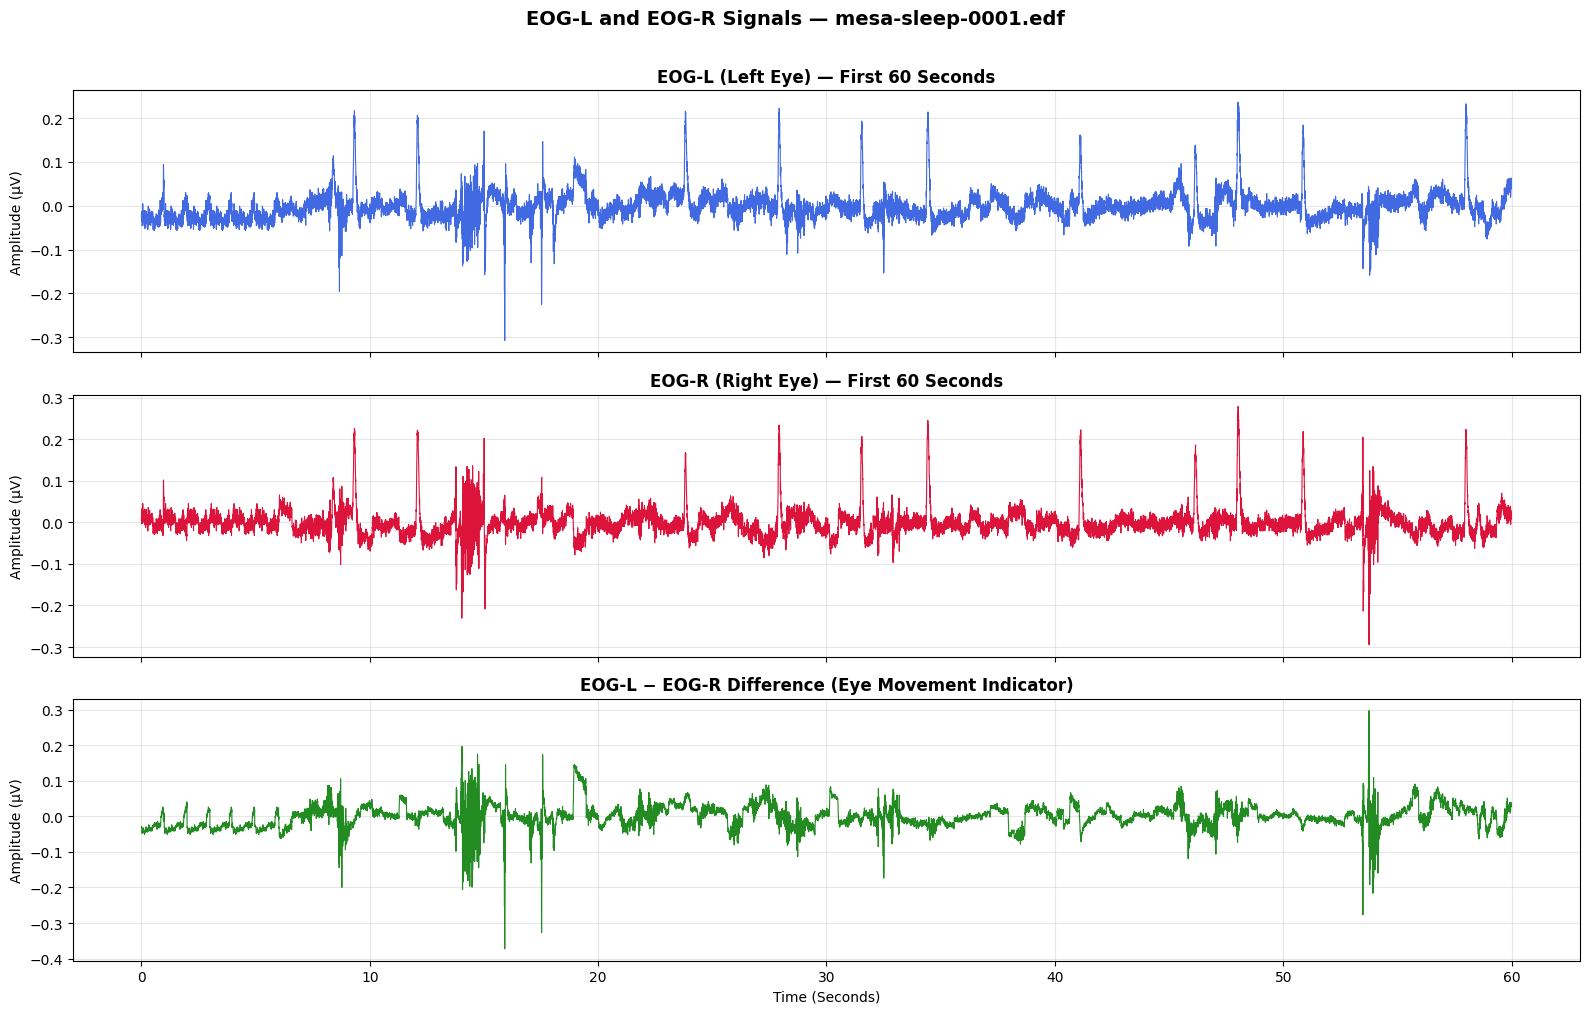

✅ Figure saved as: cell2_eog_lr.png


In [25]:
# ========================================================
# Cell 2 — Display EOG-L and EOG-R Separately
# ========================================================

import pyedflib
import numpy as np
import matplotlib.pyplot as plt

# ========================================================
# Read EOG-L and EOG-R Signals
# ========================================================

with pyedflib.EdfReader(sample_file) as f:

    ch_names = f.getSignalLabels()

    fs_list = f.getSampleFrequencies()

    # Find EOG-L and EOG-R channel indices
    eog_l_idx = next(
        (i for i, ch in enumerate(ch_names)
         if ch.strip() == 'EOG-L'),
        None
    )

    eog_r_idx = next(
        (i for i, ch in enumerate(ch_names)
         if ch.strip() == 'EOG-R'),
        None
    )

    # Check if channels exist
    if eog_l_idx is None or eog_r_idx is None:
        raise ValueError('❌ EOG-L or EOG-R channel not found in this file!')

    # Read raw signals
    eog_l_raw = f.readSignal(eog_l_idx).astype(np.float32)

    eog_r_raw = f.readSignal(eog_r_idx).astype(np.float32)

    fs = int(fs_list[eog_l_idx])

# ========================================================
# Time Axis
# ========================================================

t = np.arange(len(eog_l_raw)) / fs

show_sec = 60   # First minute

n_show = show_sec * fs

# ========================================================
# Plotting
# ========================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 10),
    sharex=True
)

# --------------------------------------------------------
# EOG-L Signal
# --------------------------------------------------------

axes[0].plot(
    t[:n_show],
    eog_l_raw[:n_show],
    color='royalblue',
    linewidth=0.8
)

axes[0].set_title(
    'EOG-L (Left Eye) — First 60 Seconds',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_ylabel('Amplitude (µV)')

axes[0].grid(True, alpha=0.3)

# --------------------------------------------------------
# EOG-R Signal
# --------------------------------------------------------

axes[1].plot(
    t[:n_show],
    eog_r_raw[:n_show],
    color='crimson',
    linewidth=0.8
)

axes[1].set_title(
    'EOG-R (Right Eye) — First 60 Seconds',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_ylabel('Amplitude (µV)')

axes[1].grid(True, alpha=0.3)

# --------------------------------------------------------
# Difference Between EOG-L and EOG-R
# --------------------------------------------------------

diff = eog_l_raw[:n_show] - eog_r_raw[:n_show]

axes[2].plot(
    t[:n_show],
    diff,
    color='forestgreen',
    linewidth=0.8
)

axes[2].set_title(
    'EOG-L − EOG-R Difference (Eye Movement Indicator)',
    fontsize=12,
    fontweight='bold'
)

axes[2].set_xlabel('Time (Seconds)')

axes[2].set_ylabel('Amplitude (µV)')

axes[2].grid(True, alpha=0.3)

# ========================================================
# Main Title
# ========================================================

plt.suptitle(
    f'EOG-L and EOG-R Signals — {files[0]}',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

# ========================================================
# Save and Display Figure
# ========================================================

plt.tight_layout()

plt.savefig(
    'cell2_eog_lr.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('✅ Figure saved as: cell2_eog_lr.png')

## 📊 Cell 3 — Compare EOG-L Signal Before and After Filtering & Preprocessing


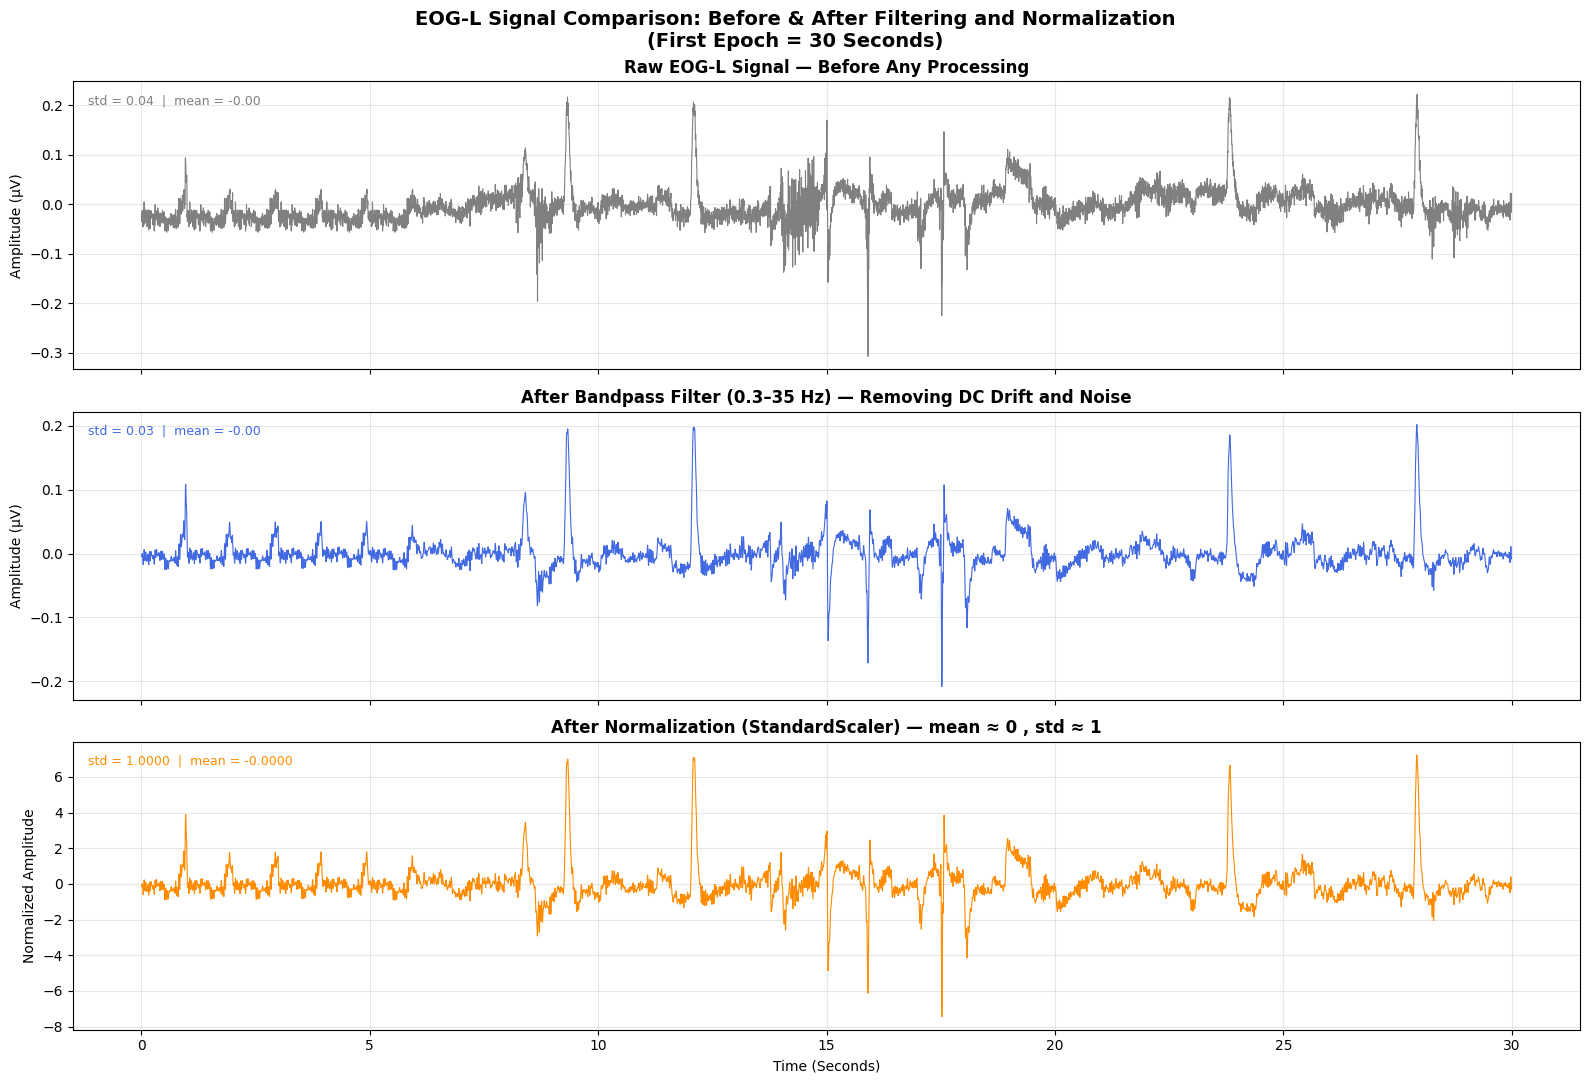

✅ Figure saved as: cell3_filter_comparison_l.png


In [26]:
# ========================================================
# Cell 3 — Compare EOG-L Signal Before & After Bandpass Filter
# and StandardScaler Normalization
# ========================================================

from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
import pyedflib
import numpy as np
import matplotlib.pyplot as plt

# ========================================================
# Read Raw EOG-L Signal
# ========================================================

with pyedflib.EdfReader(sample_file) as f:

    ch_names = f.getSignalLabels()

    fs_list = f.getSampleFrequencies()

    # Find EOG-L channel index
    eog_l_idx = next(
        (i for i, ch in enumerate(ch_names)
         if ch.strip() == 'EOG-L'),
        None
    )

    if eog_l_idx is None:
        raise ValueError("EOG-L channel not found!")

    sig_raw = f.readSignal(eog_l_idx).astype(np.float32)

    fs = int(fs_list[eog_l_idx])

# ========================================================
# Apply Bandpass Filter (0.3–35 Hz)
# ========================================================

nyquist = 0.5 * fs

b, a = butter(
    4,
    [0.3 / nyquist, 35.0 / nyquist],
    btype='band'
)

sig_filtered = filtfilt(
    b,
    a,
    sig_raw
).astype(np.float32)

# ========================================================
# Apply Normalization on First Epoch (30 Seconds)
# ========================================================

epoch_len = 30 * fs

epoch_raw = sig_raw[:epoch_len]

epoch_filt = sig_filtered[:epoch_len]

scaler = StandardScaler()

epoch_norm = scaler.fit_transform(
    epoch_filt.reshape(-1, 1)
).flatten()

# Time axis
t_epoch = np.arange(epoch_len) / fs

# ========================================================
# Plotting
# ========================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 11),
    sharex=True
)

# --------------------------------------------------------
# 1) Raw Signal
# --------------------------------------------------------

axes[0].plot(
    t_epoch,
    epoch_raw,
    color='gray',
    linewidth=0.8
)

axes[0].set_title(
    'Raw EOG-L Signal — Before Any Processing',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_ylabel('Amplitude (µV)')

axes[0].grid(True, alpha=0.3)

axes[0].annotate(
    f'std = {epoch_raw.std():.2f}  |  mean = {epoch_raw.mean():.2f}',
    xy=(0.01, 0.92),
    xycoords='axes fraction',
    fontsize=9,
    color='gray'
)

# --------------------------------------------------------
# 2) After Bandpass Filter
# --------------------------------------------------------

axes[1].plot(
    t_epoch,
    epoch_filt,
    color='royalblue',
    linewidth=0.8
)

axes[1].set_title(
    'After Bandpass Filter (0.3–35 Hz) — Removing DC Drift and Noise',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_ylabel('Amplitude (µV)')

axes[1].grid(True, alpha=0.3)

axes[1].annotate(
    f'std = {epoch_filt.std():.2f}  |  mean = {epoch_filt.mean():.2f}',
    xy=(0.01, 0.92),
    xycoords='axes fraction',
    fontsize=9,
    color='royalblue'
)

# --------------------------------------------------------
# 3) After Normalization
# --------------------------------------------------------

axes[2].plot(
    t_epoch,
    epoch_norm,
    color='darkorange',
    linewidth=0.8
)

axes[2].set_title(
    'After Normalization (StandardScaler) — mean ≈ 0 , std ≈ 1',
    fontsize=12,
    fontweight='bold'
)

axes[2].set_xlabel('Time (Seconds)')

axes[2].set_ylabel('Normalized Amplitude')

axes[2].grid(True, alpha=0.3)

axes[2].annotate(
    f'std = {epoch_norm.std():.4f}  |  mean = {epoch_norm.mean():.4f}',
    xy=(0.01, 0.92),
    xycoords='axes fraction',
    fontsize=9,
    color='darkorange'
)

# ========================================================
# Main Title
# ========================================================

plt.suptitle(
    'EOG-L Signal Comparison: Before & After Filtering and Normalization\n'
    '(First Epoch = 30 Seconds)',
    fontsize=14,
    fontweight='bold'
)

# ========================================================
# Save and Display Figure
# ========================================================

plt.tight_layout()

plt.savefig(
    'cell3_filter_comparison_l.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('✅ Figure saved as: cell3_filter_comparison_l.png')

In [ ]:
import gc

# Step 1 — Load All Subjects

# Load and preprocess all subjects
subjects = load_all_subjects(
    data_path,
    ann_path,
    seq_len=SEQ_LEN
)

# Print total number of loaded subjects
print(
    f'\nTotal subjects loaded: {len(subjects)}'
)

# Free unused memory
gc.collect()

Loaded: mesa-sleep-0001.edf — 1439 epochs → 1429 sequences
Loaded: mesa-sleep-0002.edf — 1319 epochs → 1309 sequences
Loaded: mesa-sleep-0006.edf — 1079 epochs → 1069 sequences
Loaded: mesa-sleep-0010.edf — 1199 epochs → 1189 sequences
Loaded: mesa-sleep-0012.edf — 1427 epochs → 1417 sequences
Loaded: mesa-sleep-0014.edf — 1679 epochs → 1669 sequences
Loaded: mesa-sleep-0016.edf — 1199 epochs → 1189 sequences
Loaded: mesa-sleep-0021.edf — 1079 epochs → 1069 sequences
Loaded: mesa-sleep-0027.edf — 1199 epochs → 1189 sequences
Loaded: mesa-sleep-0028.edf — 1139 epochs → 1129 sequences

Total subjects loaded: 10


18274

In [ ]:
# ============================================================
# Display Loaded Subjects Information
# ============================================================

# Print total number of subjects
print(
    "Number of subjects loaded:",
    len(subjects)
)

# Print sequence count for each subject
for i, (X, y) in enumerate(subjects):

    print(
        f"Subject {i+1}: "
        f"{len(X)} sequences"
    )

Number of subjects loaded: 10
  Subject 1: 1429 sequences
  Subject 2: 1309 sequences
  Subject 3: 1069 sequences
  Subject 4: 1189 sequences
  Subject 5: 1417 sequences
  Subject 6: 1669 sequences
  Subject 7: 1189 sequences
  Subject 8: 1069 sequences
  Subject 9: 1189 sequences
  Subject 10: 1129 sequences


In [ ]:
# ============================================================
# Check EDF Files and Annotation Files
# ============================================================

# Get all EDF files
files = sorted([

    f for f in os.listdir(data_path)

    if f.endswith('.edf')
])

# Print total number of EDF files
print(
    "EDF files found:",
    len(files)
)

for file in files:

    # Expected XML annotation file
    xml = file.replace(
        '.edf',
        '-nsrr.xml'
    )

    xml_path = os.path.join(
        ann_path,
        xml
    )

    # Check if annotation exists
    print(

        f"{file} → "
        f"annotation exists: "
        f"{os.path.exists(xml_path)}"
    )

    print(
        f"looking for: {xml_path}"
    )

EDF files found: 10
  mesa-sleep-0001.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0001-nsrr.xml
  mesa-sleep-0002.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0002-nsrr.xml
  mesa-sleep-0006.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0006-nsrr.xml
  mesa-sleep-0010.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0010-nsrr.xml
  mesa-sleep-0012.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0012-nsrr.xml
  mesa-sleep-0014.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0014-nsrr.xml
  mesa-sleep-0016.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0016-nsrr.xml
  mesa-sleep-0021.edf → annotation exists:

In [ ]:
# ============================================================
# Verify EDF Files and Display Channel Names
# ============================================================

# Get all EDF files
files = sorted([

    f for f in os.listdir(data_path)

    if f.endswith('.edf')
])

for file in files:

    edf_path = os.path.join(
        data_path,
        file
    )

    try:
        # Load EDF file
        raw = mne.io.read_raw_edf(

            edf_path,

            preload=True,

            verbose=False
        )

        # Print available channels
        print(
            f"{file} — channels: {raw.ch_names}"
        )

    except Exception as e:

        # Print loading error
        print(
            f"{file} — ERROR: {e}"
        )

✅ mesa-sleep-0001.edf — channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
✅ mesa-sleep-0002.edf — channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
✅ mesa-sleep-0006.edf — channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
✅ mesa-sleep-0010.edf — channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'E

In [ ]:
# ============================================================
# Step 2 — Subject-Level Data Split
# ============================================================

# Split data into:
# train / validation / test
X_train, X_val, X_test, y_train, y_val, y_test = split_subjects(
    subjects
)

# Print class distribution
print(

    '\nClass distribution in Train:',

    dict(
        zip(
            *np.unique(
                y_train,
                return_counts=True
            )
        )
    )
)

print(

    'Class distribution in Val:',

    dict(
        zip(
            *np.unique(
                y_val,
                return_counts=True
            )
        )
    )
)

print(

    'Class distribution in Test:',

    dict(
        zip(
            *np.unique(
                y_test,
                return_counts=True
            )
        )
    )
)

Train: 7 subjects → 9271 sequences
Val  : 2   subjects → 2258 sequences
Test : 1  subject  → 1129 sequences

Class distribution in Train: {np.int64(0): np.int64(4678), np.int64(1): np.int64(520), np.int64(2): np.int64(2587), np.int64(3): np.int64(640), np.int64(4): np.int64(846)}
Class distribution in Val  : {np.int64(0): np.int64(343), np.int64(1): np.int64(344), np.int64(2): np.int64(1148), np.int64(3): np.int64(157), np.int64(4): np.int64(266)}
Class distribution in Test : {np.int64(0): np.int64(475), np.int64(1): np.int64(70), np.int64(2): np.int64(373), np.int64(3): np.int64(62), np.int64(4): np.int64(149)}


In [ ]:
# ============================================================
# Step 3 — Compute Class Weights
# ============================================================

# Get unique classes
classes = np.unique(y_train)

# Compute balanced class weights
weights_np = compute_class_weight(

    class_weight='balanced',

    classes=classes,

    y=y_train
)

# Convert weights to tensor
weights = torch.tensor(

    weights_np,

    dtype=torch.float32
)

# Print class weights
print(

    'Class weights:',

    dict(
        zip(
            classes,
            weights_np.round(3)
        )
    )
)

Class weights: {np.int64(0): np.float64(0.396), np.int64(1): np.float64(3.566), np.int64(2): np.float64(0.717), np.int64(3): np.float64(2.897), np.int64(4): np.float64(2.192)}


In [ ]:
# ============================================================
# Step 4 — Create Datasets and DataLoaders
# ============================================================

# Create dataset objects
train_dataset = SleepDataset(
    X_train,
    y_train
)

val_dataset = SleepDataset(
    X_val,
    y_val
)

test_dataset = SleepDataset(
    X_test,
    y_test
)

# Create dataloaders
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    num_workers=0
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=0
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=0
)

# Print dataset information
print(
    'Train batches:',
    len(train_loader)
)

# Example input shape:
# (batch, seq_len, timesteps)
print(

    'Input shape sample:',

    next(iter(train_loader))[0].shape
)

Train batches: 290
Input shape sample: torch.Size([32, 10, 7680])


In [ ]:
# ============================================================
# Step 5 — Initialize Model
# ============================================================

# Create sleep staging model
model = SleepModel(

    cnn_out=128,

    lstm_hidden=256,

    lstm_layers=2,

    num_classes=5,

    dropout=0.3
)

# Print model architecture
print(model)

# Count trainable parameters
total_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

print(

    f'\nTotal trainable parameters: '
    f'{total_params:,}'
)

SleepModel(
  (cnn): CNNEncoder(
    (net): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      (4): Dropout(p=0.2, inplace=False)
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): ReLU()
      (8): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      (9): Dropout(p=0.2, inplace=False)
      (10): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (12): ReLU()
      (13): AdaptiveAvgPool1d(output_size=1)
    )
  )
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
 

In [32]:
# Step 6: Train
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, weights=weights, epochs=30
)


Using: cuda


C:\ProgramData\anaconda3\envs\torch_gpu\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/30: 100%|██████████| 290/290 [00:39<00:00,  7.34it/s]


Epoch 1: Train Loss=1.4164 Acc=0.5120 | Val Loss=1.7024 Acc=0.1510
  ✅ Saved best model


Epoch 2/30: 100%|██████████| 290/290 [00:34<00:00,  8.40it/s]


Epoch 2: Train Loss=1.3470 Acc=0.5216 | Val Loss=1.5463 Acc=0.2511
  ✅ Saved best model


...

Epoch 27: Train Loss=0.6439 Acc=0.7701 | Val Loss=0.9855 Acc=0.6045


Epoch 28/30: 100%|██████████| 290/290 [00:34<00:00,  8.41it/s]


Epoch 28: Train Loss=0.6280 Acc=0.7698 | Val Loss=0.9813 Acc=0.6041


Epoch 29/30: 100%|██████████| 290/290 [00:34<00:00,  8.45it/s]


Epoch 29: Train Loss=0.6235 Acc=0.7678 | Val Loss=1.0667 Acc=0.5859
Early stopping.


In [33]:
# Step 7: Evaluate
preds, labels = evaluate(model, test_loader)


C:\Users\Laptop\AppData\Local\Temp\ipykernel_17244\525474071.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best.pth', map_location=de

              precision    recall  f1-score   support

        Wake       1.00      0.84      0.91       475
     Stage 1       0.42      0.24      0.31        70
     Stage 2       0.79      0.50      0.61       373
   Stage 3/4       0.83      0.48      0.61        62
         REM       0.35      0.98      0.52       149

    accuracy                           0.69      1129
   macro avg       0.68      0.61      0.59      1129
weighted avg       0.80      0.69      0.71      1129

Macro F1  : 0.5937
Cohen Kappa: 0.5768


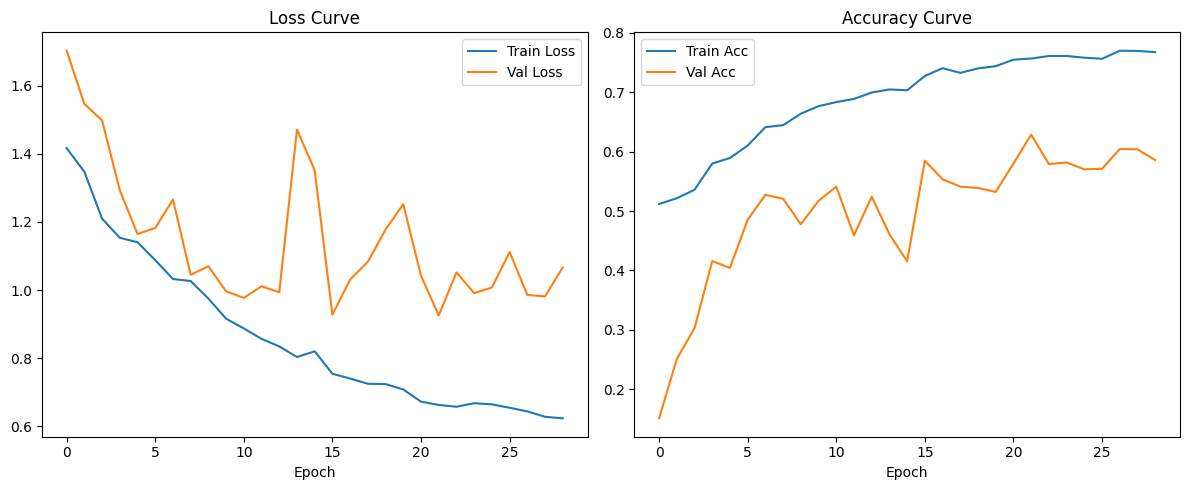

In [34]:
# Step 8: Plot training curves
plot_results(train_losses, val_losses, train_accs, val_accs)


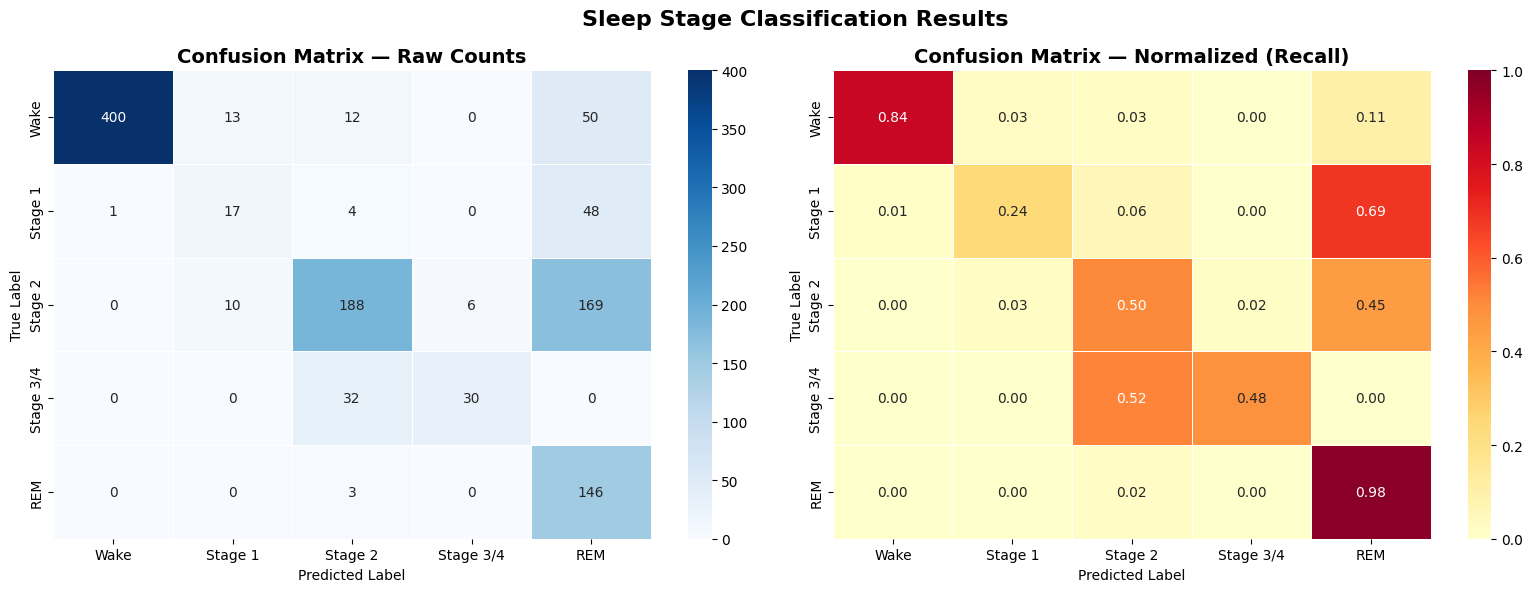

In [35]:
# Step 9: Confusion matrix
plot_confusion_matrix(labels, preds)


✅ تم الحفظ في: hypnogram.png


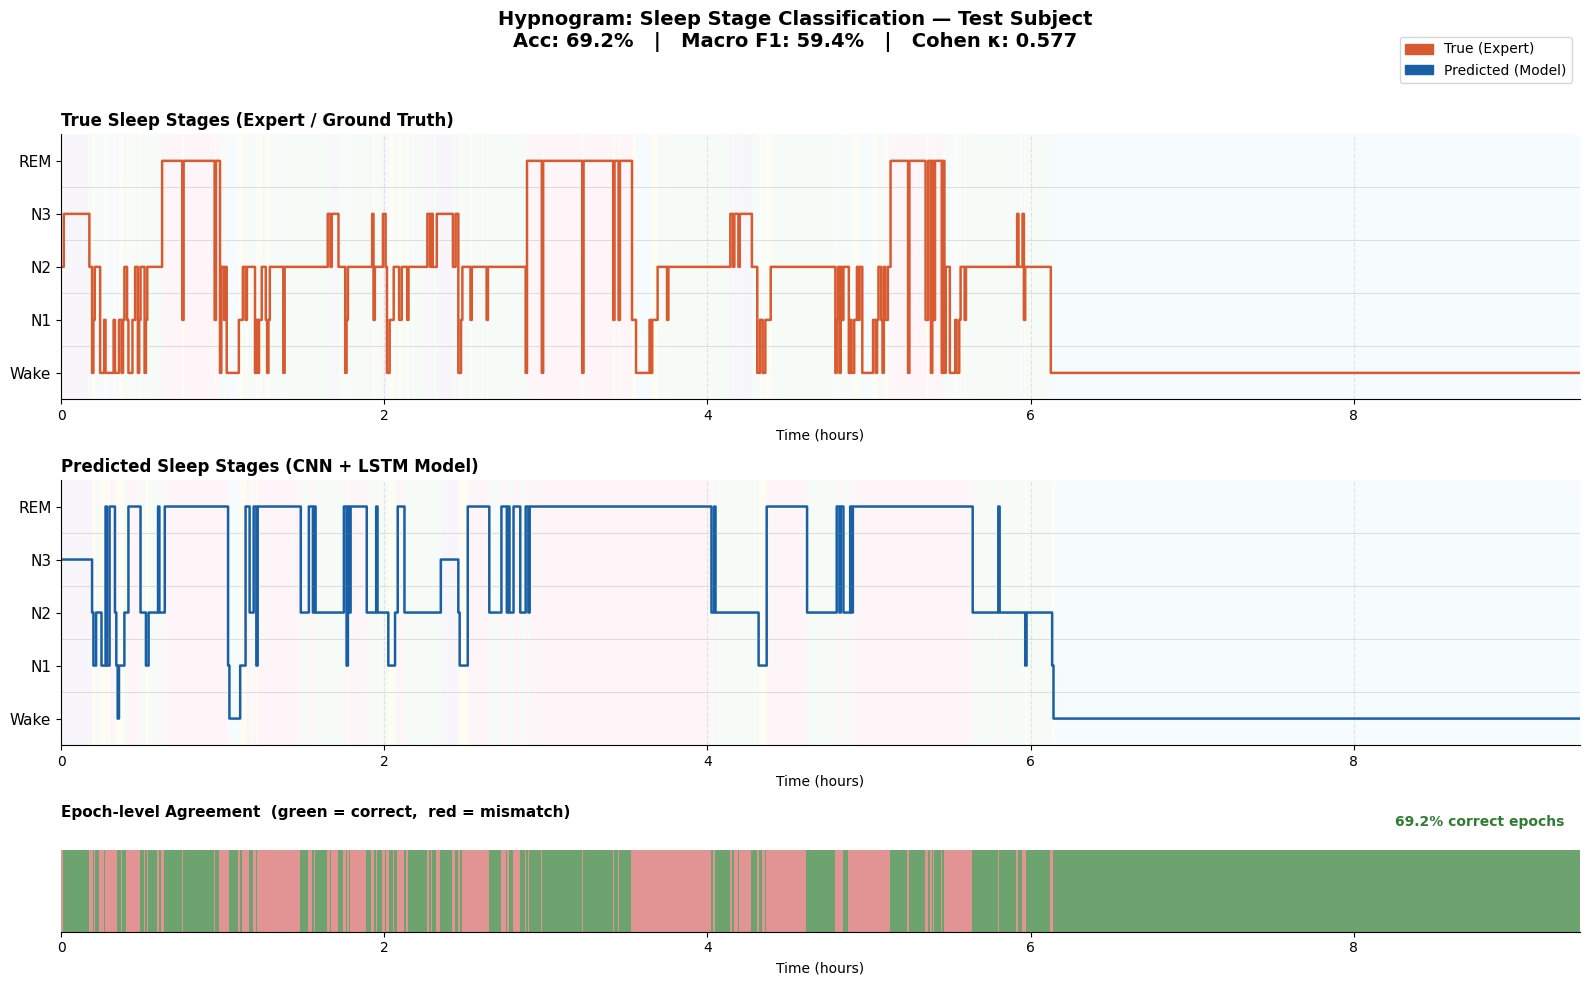

In [ ]:
# ============================================================
# Plot Hypnogram (Predicted vs True Labels)
# Run evaluate() first to get preds and labels
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score
)

def plot_hypnogram(
    preds,
    labels,
    subject_id=None,
    save_path=None
):

    """
    Compare predicted sleep stages
    with ground truth labels

    Parameters
    ----------
    preds : list or np.array
        Model predictions

    labels : list or np.array
        Ground truth labels

    subject_id : str
        Optional subject name

    save_path : str
        Optional save path
    """

    preds = np.array(preds)

    labels = np.array(labels)

    # Sleep stage names
    stage_names = [
        'Wake',
        'N1',
        'N2',
        'N3',
        'REM'
    ]

    n_epochs = len(labels)

    # Convert epochs to hours
    # Each epoch = 30 seconds
    time_hours = (
        np.arange(n_epochs) * 30 / 3600
    )

    # ============================================================
    # Compute metrics
    # ============================================================

    acc = accuracy_score(
        labels,
        preds
    ) * 100

    f1 = f1_score(

        labels,
        preds,

        average='macro',

        zero_division=0
    ) * 100

    kappa = cohen_kappa_score(
        labels,
        preds
    )

    # ============================================================
    # Background colors
    # ============================================================

    stage_colors = {

        0: '#E8F4FD',   # Wake
        1: '#FFF8E1',   # N1
        2: '#E8F5E9',   # N2
        3: '#EDE7F6',   # N3
        4: '#FCE4EC',   # REM
    }

    # ============================================================
    # Create figure
    # ============================================================

    fig, axes = plt.subplots(

        3,
        1,

        figsize=(16, 10),

        gridspec_kw={
            'height_ratios': [3, 3, 1.2]
        },

        facecolor='white'
    )

    fig.subplots_adjust(hspace=0.35)

    title_suffix = (
        f' — {subject_id}'
        if subject_id else ''
    )

    fig.suptitle(

        f'Hypnogram: Sleep Stage Classification'
        f'{title_suffix}\n'
        f'Acc: {acc:.1f}% | '
        f'Macro F1: {f1:.1f}% | '
        f'Cohen κ: {kappa:.3f}',

        fontsize=14,

        fontweight='bold',

        y=0.98
    )

    # ============================================================
    # Helper function
    # ============================================================

    def draw_hypno(
        ax,
        stages,
        color,
        title,
        linestyle='-',
        alpha=1.0
    ):

        # Draw stage background
        for i in range(n_epochs - 1):

            ax.axvspan(

                time_hours[i],
                time_hours[i + 1],

                facecolor=stage_colors[stages[i]],

                alpha=0.35,

                linewidth=0
            )

        # Plot hypnogram
        ax.step(

            time_hours,
            stages,

            where='post',

            color=color,

            linewidth=1.8,

            linestyle=linestyle,

            alpha=alpha
        )

        ax.set_yticks([0, 1, 2, 3, 4])

        ax.set_yticklabels(
            stage_names,
            fontsize=11
        )

        # Clinical standard:
        # Wake on top
        ax.invert_yaxis()

        ax.set_xlim(
            0,
            time_hours[-1]
        )

        ax.set_ylim(-0.5, 4.5)

        ax.set_xlabel(
            'Time (hours)',
            fontsize=10
        )

        ax.set_title(

            title,

            fontsize=12,

            fontweight='bold',

            loc='left',

            pad=6
        )

        ax.grid(
            axis='x',
            linestyle='--',
            alpha=0.3
        )

        # Remove extra borders
        ax.spines[
            ['top', 'right']
        ].set_visible(False)

        # Horizontal separators
        for y in [0.5, 1.5, 2.5, 3.5]:

            ax.axhline(

                y,

                color='gray',

                linewidth=0.4,

                alpha=0.4
            )

    # ============================================================
    # Plot ground truth labels
    # ============================================================

    draw_hypno(

        axes[0],

        labels,

        color='#D85A30',

        title='True Sleep Stages (Ground Truth)'
    )

    # ============================================================
    # Plot predicted labels
    # ============================================================

    draw_hypno(

        axes[1],

        preds,

        color='#185FA5',

        title='Predicted Sleep Stages (CNN + LSTM Model)'
    )

    # ============================================================
    # Plot agreement bar
    # ============================================================

    ax3 = axes[2]

    agree = (
        preds == labels
    ).astype(int)

    disagree = 1 - agree

    ax3.bar(

        time_hours,
        agree,

        width=30 / 3600,

        color='#2E7D32',

        alpha=0.7,

        label='Correct'
    )

    ax3.bar(

        time_hours,
        disagree,

        width=30 / 3600,

        color='#C62828',

        alpha=0.5,

        label='Mismatch',

        bottom=0
    )

    ax3.set_xlim(
        0,
        time_hours[-1]
    )

    ax3.set_ylim(0, 1.3)

    ax3.set_yticks([])

    ax3.set_xlabel(
        'Time (hours)',
        fontsize=10
    )

    ax3.set_title(

        'Epoch-Level Agreement '
        '(green = correct, red = mismatch)',

        fontsize=11,

        fontweight='bold',

        loc='left',

        pad=6
    )

    # Remove extra borders
    ax3.spines[
        ['top', 'right', 'left']
    ].set_visible(False)

    # Agreement percentage
    correct_pct = agree.mean() * 100

    ax3.text(

        0.99,
        1.1,

        f'{correct_pct:.1f}% correct epochs',

        transform=ax3.transAxes,

        ha='right',
        va='top',

        fontsize=10,

        color='#2E7D32',

        fontweight='bold'
    )

    # ============================================================
    # Shared legend
    # ============================================================

    legend_patches = [

        mpatches.Patch(
            color='#D85A30',
            label='True'
        ),

        mpatches.Patch(
            color='#185FA5',
            label='Predicted'
        ),
    ]

    fig.legend(

        handles=legend_patches,

        loc='upper right',

        bbox_to_anchor=(0.99, 0.96),

        fontsize=10,

        framealpha=0.8
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    # Save figure
    if save_path:

        plt.savefig(

            save_path,

            dpi=150,

            bbox_inches='tight'
        )

        print(
            f'Figure saved as: {save_path}'
        )

    plt.show()


# ============================================================
# Example usage
# ============================================================

# Run after:
# preds, labels = evaluate(model, test_loader)

plot_hypnogram(

    preds=preds,

    labels=labels,

    subject_id='Test Subject',

    save_path='hypnogram.png'
)